In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install osmnx==1.9.1 networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 kB 2.6 MB/s eta 0:00:0000:01


In [5]:

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt


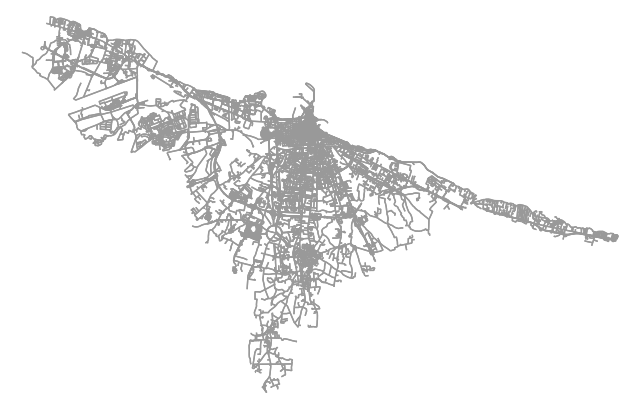

In [10]:
G = ox.graph_from_place("Bari, Italy", network_type="walk")
fig, ax = ox.plot_graph(G, node_size=0, bgcolor="white")

In [7]:
import requests
import json

#defining q is like defining a bbox on the zone of the city you're studying.
q = """
[out:json][timeout:25];
node["highway"="street_lamp"](41.115,16.83,41.15,16.90);
out;
"""

url = "https://overpass.kumi.systems/api/interpreter"

response = requests.get(url, params={"data": q})

# Debug: stampa primi 200 caratteri
print(response.text[:200])

# Se è JSON valido:
data = response.json()
lamps = data.get("elements", [])
print("Lampioni trovati:", len(lamps))

{
  "version": 0.6,
  "generator": "Overpass API 0.7.61.8 b1080abd",
  "osm3s": {
    "timestamp_osm_base": "2026-02-16T14:09:02Z",
    "copyright": "The data included in this document is from www.ope
Lampioni trovati: 245


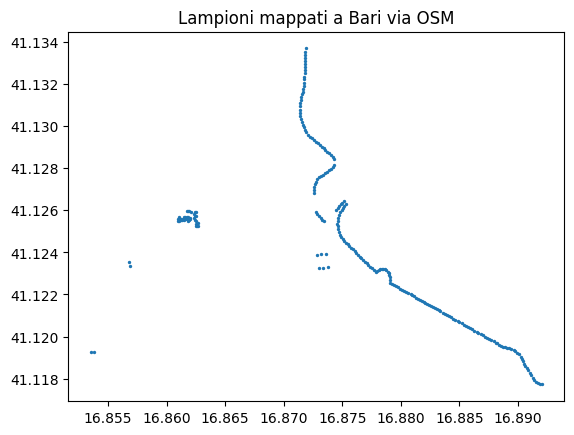

In [8]:
#convertiamo i lampioni in un heatmap
xs = [l["lon"] for l in lamps]
ys = [l["lat"] for l in lamps]


plt.scatter(xs, ys, s=2)
plt.title("Lampioni mappati a Bari via OSM")
plt.show()

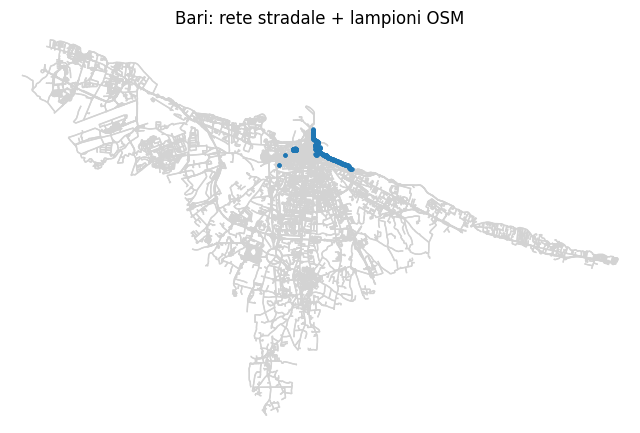

In [11]:
import matplotlib.pyplot as plt
import osmnx as ox

# 1) estrai le coordinate dei lampioni
xs = [l["lon"] for l in lamps]
ys = [l["lat"] for l in lamps]

# 2) disegna la rete stradale di Bari
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="lightgrey",
    bgcolor="white",
    show=False,
    close=False
)

# 3) sovrapponi i lampioni
ax.scatter(xs, ys, s=5)          # puoi mettere alpha=0.6 se vuoi
plt.title("Bari: rete stradale + lampioni OSM")
plt.show()